# Analysisof of SW QTSA classical Model
Compatible with PyTorch 2.5.1+

### Author
- October 2022: Prepared for Workshop on Quantum Machine Learning, 13 October 2022, organised in collaboration with QWorld, QPoland, QIndia and Quantum AI Foundation. In association with IEEE Conference Trends in Quantum Computing and Emerging Business Technologies - TQCEBT 2022
- Feb 2025: Changed to PyTorch
- Feb 2025: Addition of model instances

### Aims
> *This script aims to fit time series data with a classical quantum neural network.*

### Note
> *<font color="tomato">When running this script, you are likely to obtain slightly different results each time.</font>*

In [1]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.',
 '..']

In [2]:
import os
import numpy as np
import pylab
import math
import json
import copy
import time
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Window import *
# from utils.TS import *
from utils.Charts import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *
from utils.Models import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
### Libraries used in QTSA development
import torch
from torch import nn, tensor, optim
from torch.utils.data import DataLoader, Dataset

In [4]:
### Listing control
debug = True
seed = 2022

### Software version
MAJOR = 9
MINOR = 13

### Constants
LOG_NAME = '../log_4_iter'
CASE_NAME = 'cnn'
DATA_NAME = '2_sins_sw'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, CASE_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, ANALYSIS_PATH, FIGURES_PATH)

('../log_4_iter',
 'cnn',
 '2_sins_sw',
 '../log_4_iter/data',
 '../log_4_iter/training',
 '../log_4_iter/analysis',
 '../log_4_iter/figures')

## Utils

In [5]:
def rand_seed():
    t=time.time(); t = int((t-int(t))*10000)
    return t

## Fetch data
**<font color="red">Enter the name of the DATA_ID</font>**<br/>
*Note that this is windowed TS data (as indicated by "sw" in the data ID)*

In [6]:
### All created files have the following codes:
DATA_ID = '2_sins_sw_t50_v20_z0_w5_s1_h1'

### Define file names

x_all_fpath = f'{DATA_PATH}/{DATA_ID}/x_all.arr'
y_all_fpath = f'{DATA_PATH}/{DATA_ID}/y_all.arr'

x_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_train_ts.arr'
y_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_train_ts.arr'
x_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_valid_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_valid_ts.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_ID}/info.json'
data_info_fpath

'../log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json'

In [7]:
### Load the info file
data_info = read_json_file(data_info_fpath)
    
### Get info details
DATA_NAME = data_info['data_name']
DATA_MAJOR = data_info['major_version'] 
DATA_MINOR = data_info['minor_version']
samples_train = data_info['data_train']
samples_valid = data_info['data_valid']
noise = data_info['data_noise']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['wind_horizon']
seed = data_info['seed']
samples = samples_train + samples_valid
train_pc = samples_train / samples

print(f'\nSaved time series info in file "{data_info_fpath}":\n')
for k in data_info.keys():
    print(f'\tinfo[{k}] = {data_info[k]}')
print()
print(f'\tcalc[samples] = {samples}')
print(f'\tcalc[train_pc] = {train_pc}')
print()


Saved time series info in file "../log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json":

	info[data_name] = 2_sins_sw
	info[major_version] = 9
	info[minor_version] = 0
	info[data_train] = 50
	info[data_valid] = 20
	info[data_noise] = 0
	info[wind_size] = 5
	info[wind_step] = 1
	info[wind_horizon] = 1
	info[seed] = 2022

	calc[samples] = 70
	calc[train_pc] = 0.7142857142857143



In [8]:
### Load data files
X_all = read_ts_file(x_all_fpath)[..., None]
y_all = read_ts_file(y_all_fpath)
X_train_ts = read_ts_file(x_train_ts_fpath)
y_train_ts = read_ts_file(y_train_ts_fpath)[..., None]
X_valid_ts = read_ts_file(x_valid_ts_fpath)
y_valid_ts = read_ts_file(y_valid_ts_fpath)[..., None]
print(f'\nLoaded time series data\n')


Loaded time series data



## Fetch all training meta-data
**<font color="red">Enter the name of the TRAIN_ID</font>**

In [9]:
### Training parameters

### All created files have the following codes:
#   n: sample size
#   z: level of noise injected
#   q: number of qubits
#   fm: number of fm layers
#   anz: number of ansatz layers
#   opt_name: name of the optimiser
#   ep: number of "maxiter" epochs

TRAIN_ID = '2_sins_sw_cnn_n70_z0_hl010_015_010_LBFGS_ep60'
train_info_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/info.json'
train_info_fpath

'../log_4_iter/training/2_sins_sw_cnn_n70_z0_hl010_015_010_LBFGS_ep60/info.json'

In [10]:
## Fetch all training parameters
### Reading the info file
train_info = read_json_file(train_info_fpath)

print(f'\nLoaded QTSA from a file "{train_info_fpath}":\n')
for k in train_info.keys():
    print(f'\tinfo[{k}] = {train_info[k]}')
    # print(f"{k} = train_info['{k}']")
print()

CASE_NAME = train_info['case_name']
MAJOR = train_info['major_version']
MINOR = train_info['minor_version']
DATA_NAME = train_info['data_name']
samples = train_info['data_sample']
train_pc = train_info['data_split']
noise = train_info['data_noise']
inputs = train_info['model_inputs']
layers = train_info['model_layers']
outputs = train_info['model_outputs']
log_interv = train_info['log_interv']
opt_name = train_info['opt_name']
epochs = train_info['epochs']
seed = train_info['seed']
inst_no = train_info['inst_no']
inst_seeds = train_info['inst_seeds']


Loaded QTSA from a file "../log_4_iter/training/2_sins_sw_cnn_n70_z0_hl010_015_010_LBFGS_ep60/info.json":

	info[case_name] = cnn
	info[major_version] = 9
	info[minor_version] = 13
	info[data_name] = 2_sins_sw
	info[data_sample] = 70
	info[data_split] = 0.7142857142857143
	info[data_noise] = 0
	info[model_inputs] = 5
	info[model_layers] = [10, 15, 10]
	info[model_outputs] = 1
	info[log_interv] = 1
	info[opt_name] = LBFGS
	info[epochs] = 60
	info[seed] = 2022
	info[inst_no] = 10
	info[inst_seeds] = [4989, 1244, 173, 4720, 6384, 8024, 2066, 24, 7477, 8203]



## Plot data

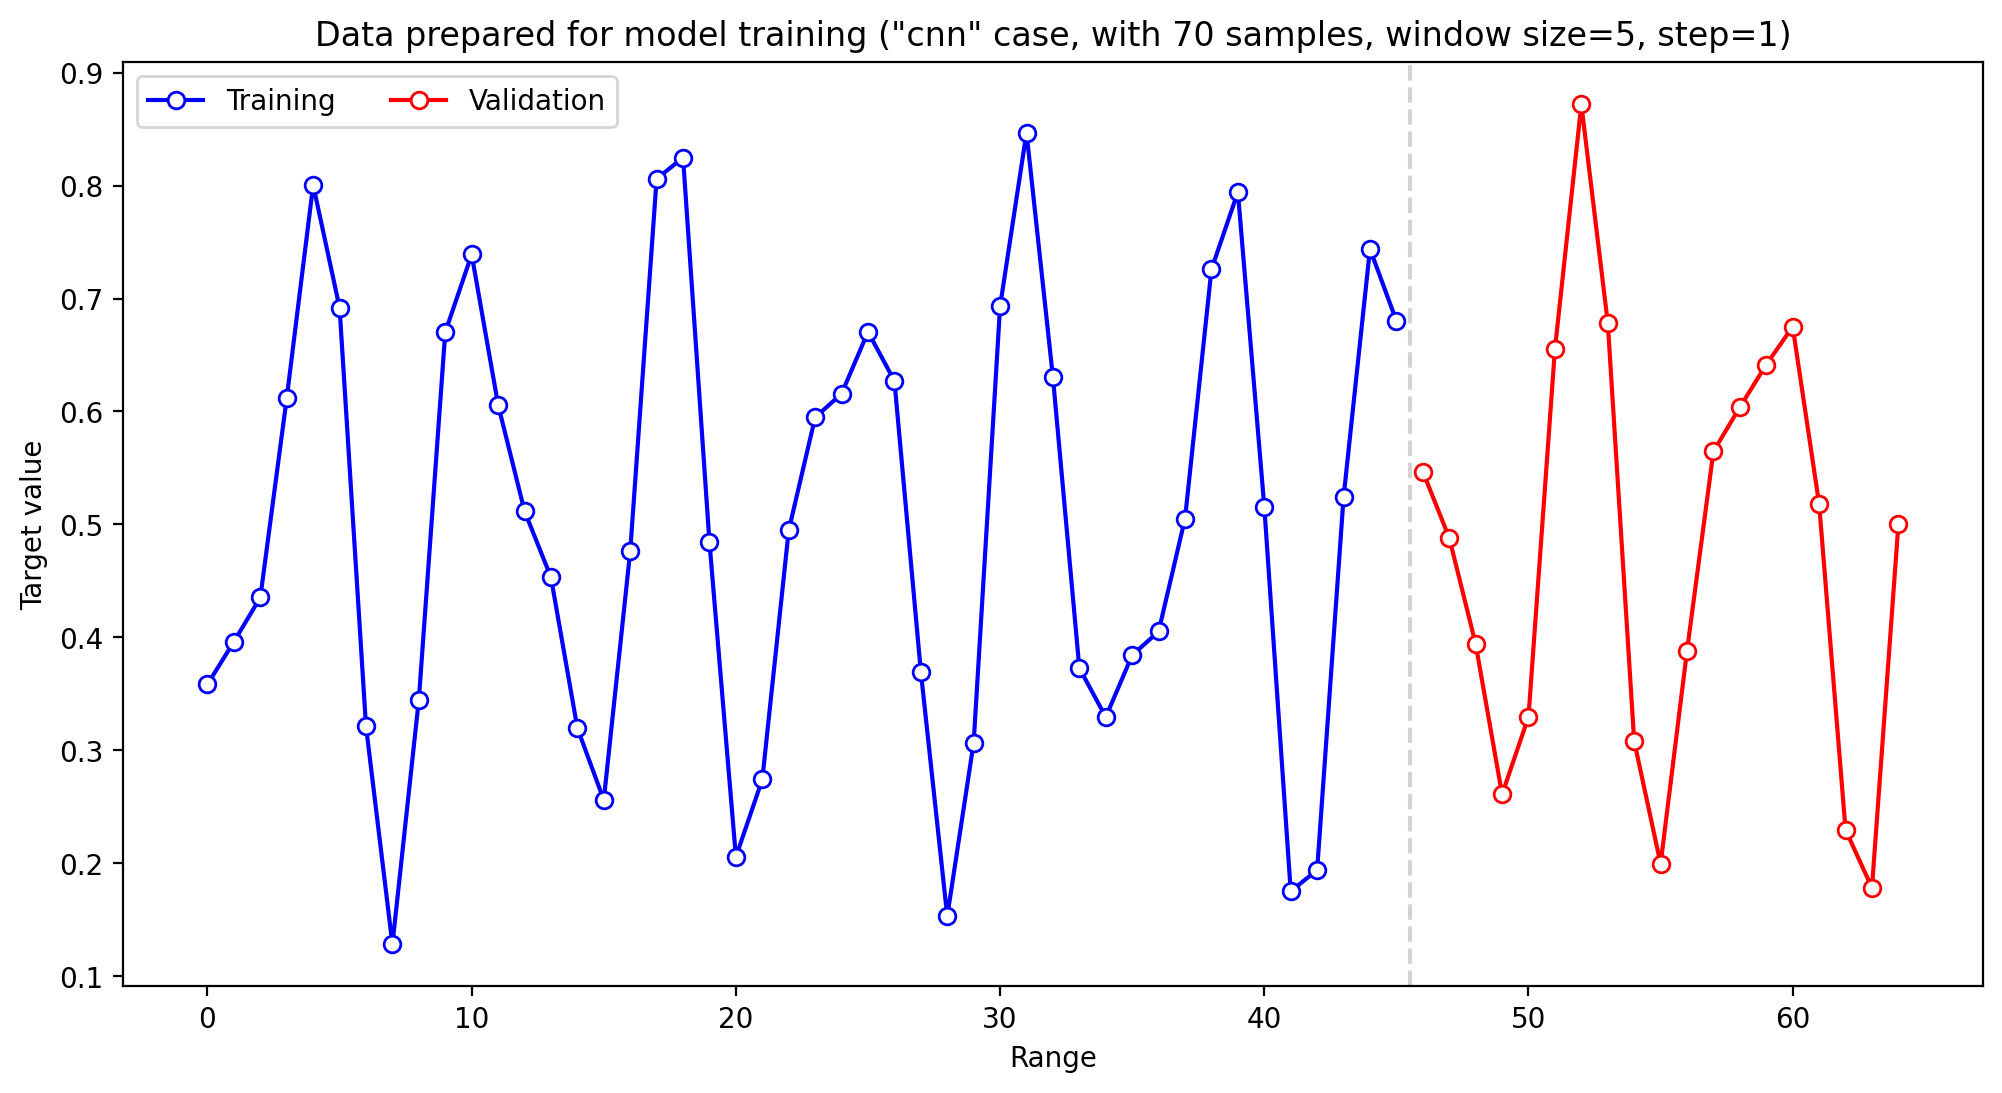

In [11]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_list = [y_train_flat_ts, y_valid_flat_ts]
X_list = [0, len(y_train_flat_ts)]

print()
multi_plot_flat_ts(y_list, X_list=X_list, 
    colors = ['blue', 'red'], marker_colors=['white', 'white', 'lightblue', 'mistyrose'],
    labels = ['Training', 'Validation'], #ylim=(0.1, 1),
    lines = ['solid', 'solid'], markers = ['o', 'o'], legend_cols=2,
    rcParams=(12, 6), dpi=200, 
    title=f'Data prepared for model training ("{CASE_NAME}" case, '+
          f'with {samples} samples, window size={wind_size}, step={wind_step})')
print()

## Utilities

In [12]:
### Counts the number of pytorch model parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Gets all pytorch parameters
def get_param_vals(model):
    params = []
    for param in model.parameters():
        params.append(param.view(-1))
    params = torch.cat(params)
    params = params.cpu().detach().flatten() # [0]
    return params.numpy()

### Find sizes of all Linear layers
def model_layer_sizes(model):
    out_lay_sizes = []
    for name, layer in model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            out_lay_sizes.append(layer.out_features)
    in_lay_sizes = []
    for name, layer in model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            in_lay_sizes.append(layer.in_features)
    in_lay_sizes[0]
    return in_lay_sizes[0], out_lay_sizes[:-1], out_lay_sizes[-1]

## Fetch all training parameters and cost history

In [13]:
### Reconstruct training prefix
ANALYSIS_PREF = TRAIN_ID

In [14]:
### Collect all instance numbers
inst_list = []
for sel_inst in range(inst_no):
    
    ### Training info files 
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.pkl'
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.pkl'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.pkl'

    ### Check if any of the files are missing
    if  not if_path_exists(init_fpath) or \
        not if_path_exists(history_fpath) or \
        not if_path_exists(params_fpath):
        print(f'*** ERROR: Incomplete instance: {os.path.basename(os.path.dirname(init_fpath))}')
    else:
        inst_list.append(sel_inst)

print(f'\nFound instances: {inst_list}\n')


Found instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



In [15]:
### Initialise all instance lists
insts_init_weights = []
insts_objfun_vals = []
insts_params_vect = []

### Collect all valid instance data
for sel_inst in inst_list:
    ### Training info files 
    history_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/hist.pkl'
    init_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/init.pkl'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_ID}/inst_{sel_inst:03d}/params.pkl'

    ### Read training data
    objfun_vals = read_pickle_file(history_fpath)
    init_weights = read_pickle_file(init_fpath)
    params_vals = read_pickle_file(params_fpath)
    insts_init_weights.append(init_weights)
    insts_objfun_vals.append(objfun_vals)
    insts_params_vect.append(params_vals)

print(f'\nCollected instances: {inst_list}\n')


Collected instances: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



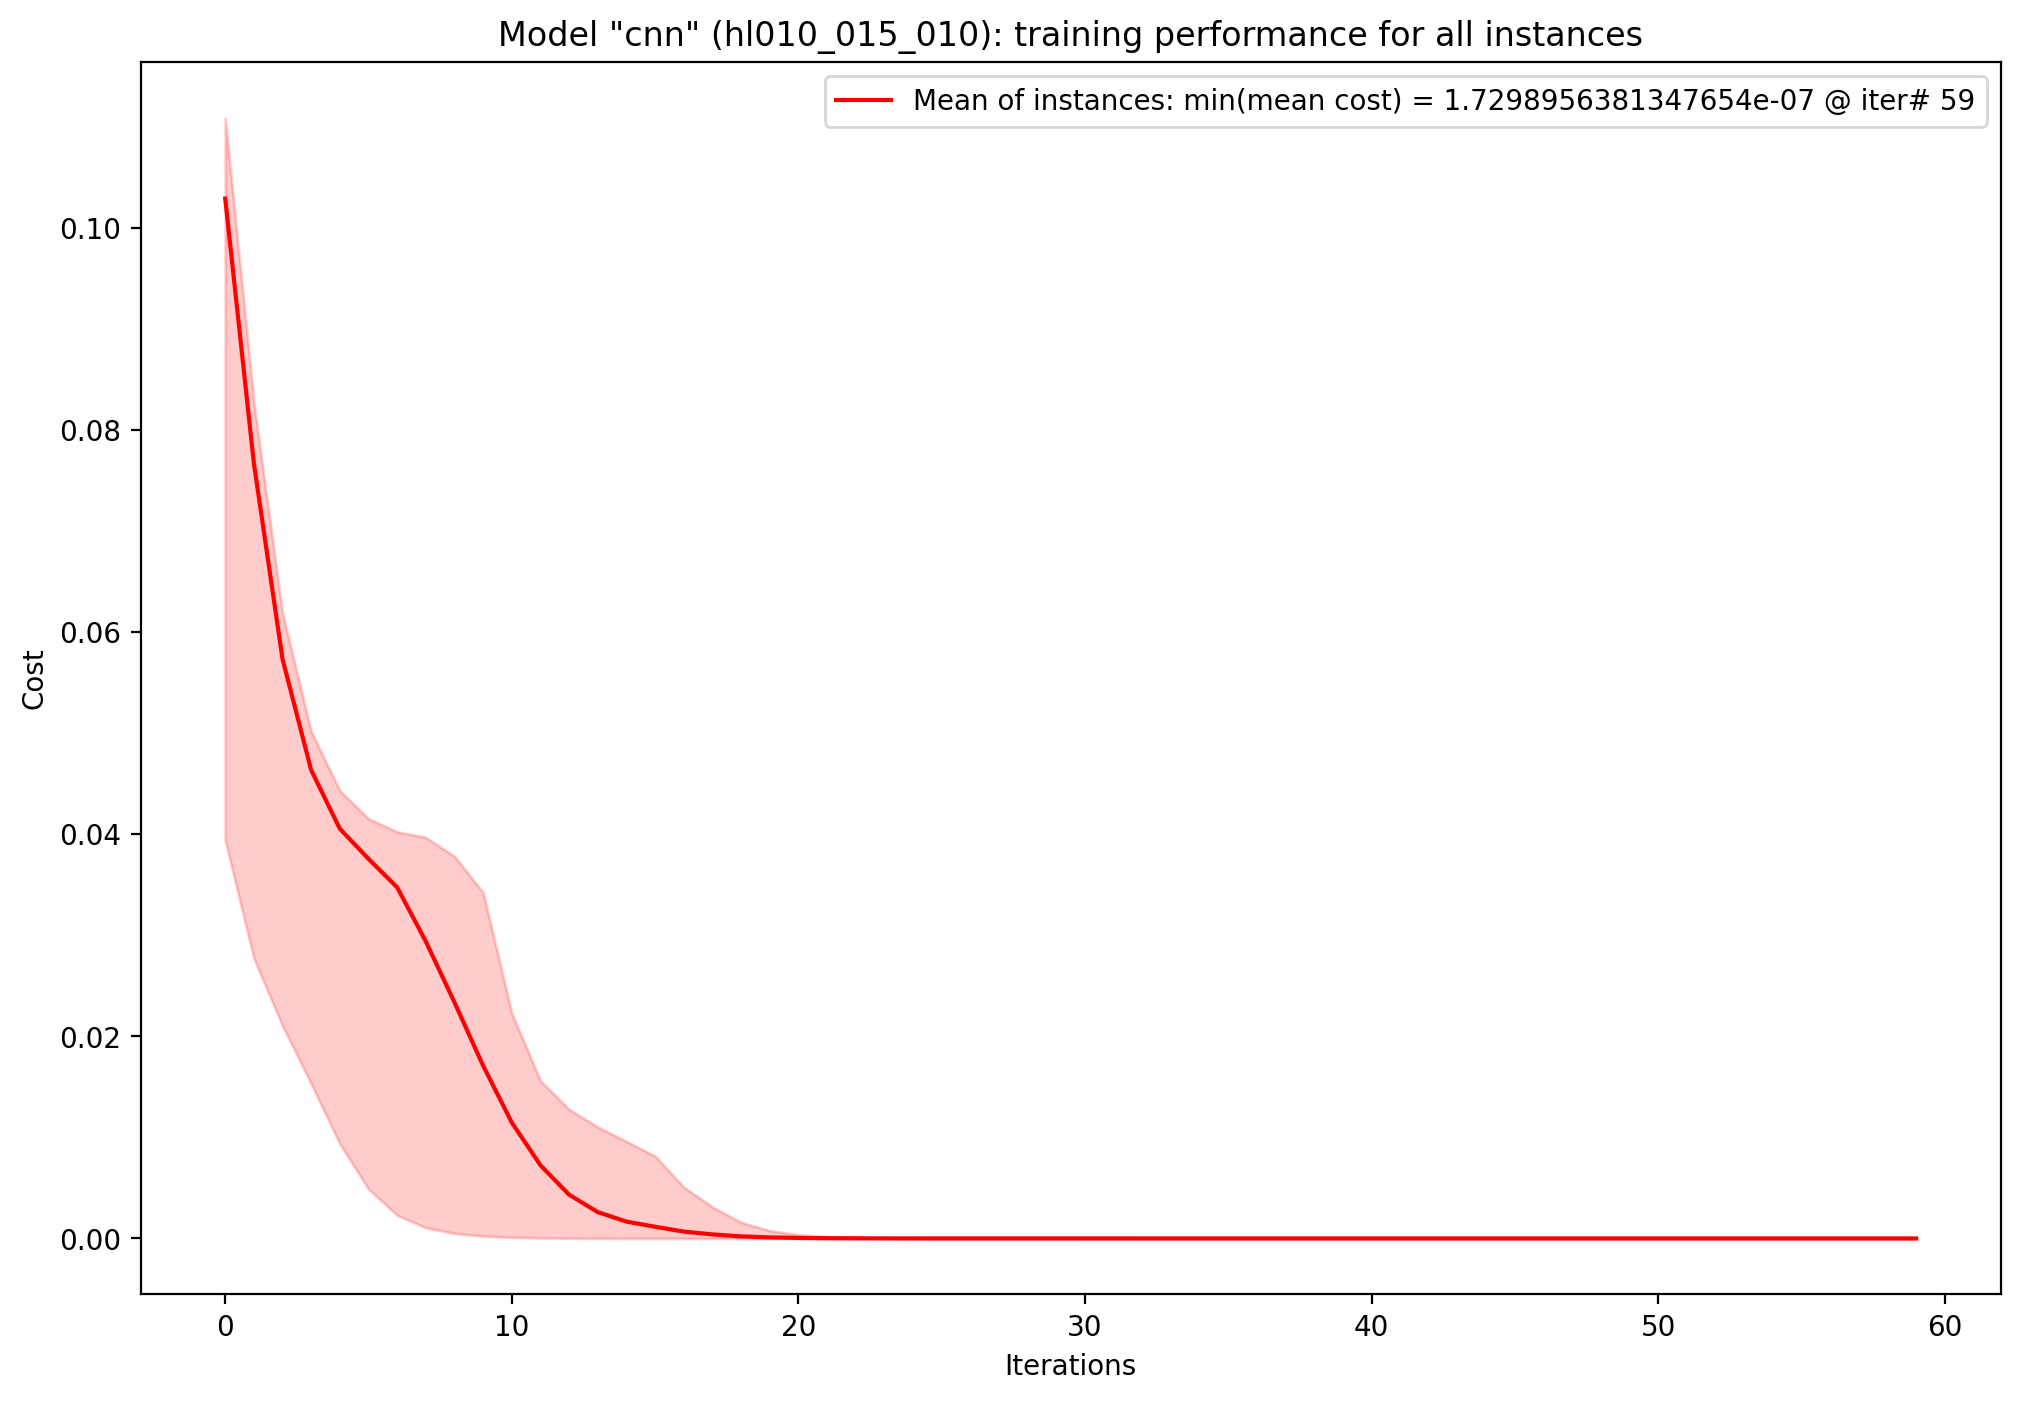

In [16]:
### Plot a list of objective function instances 
### Each objective function value could be of different length
model_descr = '_'.join([f'{l:03d}' for l in layers])
range_plot_path = f'{FIGURES_PATH}/{ANALYSIS_PREF}/xfig_anlz_{CASE_NAME}_'+\
    f'hl{model_descr}_loaded_cost_range.png'
plot_objfn_range([insts_objfun_vals], smooth_weight=0.4, log_interv=log_interv, ylabel=f'Cost', 
    title=f'Model "{CASE_NAME}" (hl{model_descr}): '+
          f'training performance for all instances', prec=40,
    rcParams=(12, 8), dpi=200, objfn_list=['Mean of instances'], #xlim=(-1, 30),
    save_plot=range_plot_path
    )

## Score classical SW QTSA model

## Identify device

In [17]:
# Type to be used with tensors
dtype = torch.float32 # torch.float64
torch.set_default_dtype(dtype)

# Enable CUDA device if available
device = torch.device("cuda:0" if torch.cuda. is_available() else "cpu")
# device = "cpu"
print(f'Torch device to be used:  {device}, dtype={dtype}\n')

Torch device to be used:  cuda:0, dtype=torch.float32



## Preparing data for PyTorch

In [18]:
# Convert to PyTorch tensors
X_train_tens = torch.tensor(X_train_ts, dtype=dtype).to(device)
y_train_tens = torch.tensor(y_train_ts, dtype=dtype).to(device)
X_valid_tens = torch.tensor(X_valid_ts, dtype=dtype).to(device)
y_valid_tens = torch.tensor(y_valid_ts, dtype=dtype).to(device)

## Score the model

In [19]:
##### Calculate the score

### Init predictions for all instances
insts_train_preds = []
insts_test_preds = []

### Init scores
insts_train_mae_scores = []
insts_train_mse_scores = []
insts_train_r2_scores = []
insts_test_mae_scores = []
insts_test_mse_scores = []
insts_test_r2_scores = []

# Init MSE tracking
min_test_mse = 100000
min_test_mse_idx = 0

for inst_idx in tqdm(range(len(inst_list)), desc=f"Instances progress: "):
    
    ### Find real instance number
    sel_inst = inst_list[inst_idx]

    ### Start a random process
    np.random.seed(inst_seeds[sel_inst])
    torch.manual_seed(inst_seeds[sel_inst])
    torch.cuda.manual_seed(inst_seeds[sel_inst])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    ### Init predictions
    train_preds = []
    test_preds = []

    ### Init scores
    train_mae_scores = []
    train_mse_scores = []
    train_r2_scores = []
    test_mae_scores = []
    test_mse_scores = []
    test_r2_scores = []
    
    ### Fetch the instance parameters
    params_vals = insts_params_vect[inst_idx]

    ### Score calculation and collection
    start = time.time()
    for param_no in tqdm(range(params_vals.shape[0]), leave=False,
                         desc=f'Instance {sel_inst:03d} progress: '):
        
        # Define model, its parameters and their values
        sel_weights = params_vals[param_no]
        class_nn = Classic_NN_Small(in_shape=X_train_tens.shape[1], 
            out_shape=y_train_tens.shape[1]).to(device).float()
        class_nn.load_state_dict(sel_weights)
        
        # Use train() mode for inference to match training-time BatchNorm behavior
        # Since we trained on the full dataset as one batch, 
        # eval() would use outdated running stats
        class_nn.train()
             
        # Calculate results
        with torch.no_grad():
            yp_train_true = y_train_tens.cpu().flatten().numpy()
            yp_train_hat = class_nn(X_train_tens)
            yp_train_hat = yp_train_hat.cpu().flatten().numpy()
            yp_valid_true = y_valid_tens.cpu().flatten().numpy()
            yp_valid_hat = class_nn(X_valid_tens)
            yp_valid_hat = yp_valid_hat.cpu().flatten().numpy()
            
        train_r2 = r2_score(yp_train_true, yp_train_hat)
        train_mae = mean_absolute_error(yp_train_true, yp_train_hat)
        train_mse = mean_squared_error(yp_train_true, yp_train_hat)
        
        test_r2 = r2_score(yp_valid_true, yp_valid_hat)
        test_mae = mean_absolute_error(yp_valid_true, yp_valid_hat)
        test_mse = mean_squared_error(yp_valid_true, yp_valid_hat)

        # Check if this instance has the best test MSE
        this_min_test_mse = np.min(test_mse)
        if this_min_test_mse < min_test_mse:
            min_test_mse = this_min_test_mse
            min_test_mse_idx = inst_idx
    
        # Add predictions to their lists
        train_preds.append(yp_train_hat)
        test_preds.append(yp_valid_hat)

        # Add scores to their lists
        train_mae_scores.append(train_mae)
        train_mse_scores.append(train_mse)
        train_r2_scores.append(train_r2)
        test_mae_scores.append(test_mae)
        test_mse_scores.append(test_mse)
        test_r2_scores.append(test_r2)

    insts_train_preds.append(train_preds)
    insts_test_preds.append(test_preds)
    insts_train_mae_scores.append(train_mae_scores)
    insts_train_mse_scores.append(train_mse_scores)
    insts_train_r2_scores.append(train_r2_scores)
    insts_test_mae_scores.append(test_mae_scores)
    insts_test_mse_scores.append(test_mse_scores)
    insts_test_r2_scores.append(test_r2_scores)

elapsed = time.time() - start

Instances progress:   0%|          | 0/10 [00:00<?, ?it/s]

Instance 000 progress:   0%|          | 0/60 [00:00<?, ?it/s]

Instance 001 progress:   0%|          | 0/60 [00:00<?, ?it/s]

Instance 002 progress:   0%|          | 0/60 [00:00<?, ?it/s]

Instance 003 progress:   0%|          | 0/60 [00:00<?, ?it/s]

...

Instance 005 progress:   0%|          | 0/60 [00:00<?, ?it/s]

Instance 006 progress:   0%|          | 0/60 [00:00<?, ?it/s]

Instance 007 progress:   0%|          | 0/60 [00:00<?, ?it/s]

Instance 008 progress:   0%|          | 0/60 [00:00<?, ?it/s]

Instance 009 progress:   0%|          | 0/60 [00:00<?, ?it/s]

In [20]:
print(f'\nMinimum test MSE: {min_test_mse:5e}, '+
      f'found in instance[#{min_test_mse_idx}] = {inst_list[min_test_mse_idx]} / '+
      f'time: {np.round(elapsed, 4)} secs\n')


Minimum test MSE: 6.647517e-04, found in instance[#4] = 4 / time: 0.0973 secs



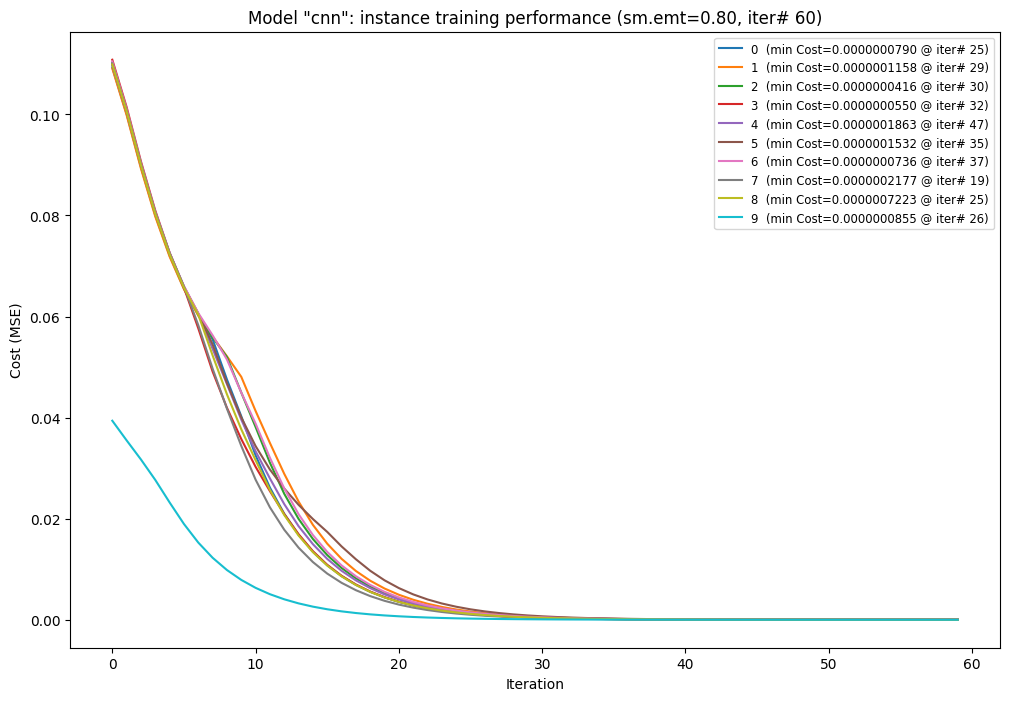

In [21]:
### Plot all trained instances
multi_perform_plot(insts_train_mse_scores, log_interv=log_interv, smooth_weight=0.8, prec=10,
    rcParams=(12, 8), dpi=100, meas_type=f'Cost', ylabel=f'Cost (MSE)', # xlim=(-0.5, 20), # yscale='log',
    title=f'Model "{CASE_NAME}": instance training performance', opt_format='0.10f'
    )

## Save analysis and prediction data for all instances

In [22]:
print(f'Saved model scores for instances: ', end='')
for inst_idx in range(len(inst_list)):
    
    ### Find real instance number
    sel_inst = inst_list[inst_idx]

    ### Training info files 
    train_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_preds.pkl'
    train_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mae_scores.pkl'
    train_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_mse_scores.pkl'
    train_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/train_r2_scores.pkl'

    test_preds_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_preds.pkl'
    test_mae_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mae_scores.pkl'
    test_mse_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_mse_scores.pkl'
    test_r2_scores_fpath = f'{ANALYSIS_PATH}/{ANALYSIS_PREF}/anlz_{sel_inst:03d}/test_r2_scores.pkl'
    train_mae_scores_fpath

    ### Save the scores
    write_pickle_file(train_preds_fpath, insts_train_preds[sel_inst])
    write_pickle_file(train_mae_scores_fpath, insts_train_mae_scores[sel_inst])
    write_pickle_file(train_mse_scores_fpath, insts_train_mse_scores[sel_inst])
    write_pickle_file(train_r2_scores_fpath, insts_train_r2_scores[sel_inst])

    write_pickle_file(test_preds_fpath, insts_test_preds[sel_inst])
    write_pickle_file(test_mae_scores_fpath, insts_test_mae_scores[sel_inst])
    write_pickle_file(test_mse_scores_fpath, insts_test_mse_scores[sel_inst])
    write_pickle_file(test_r2_scores_fpath, insts_test_r2_scores[sel_inst])
    print(f'{sel_inst} ', end='')

print()

Saved model scores for instances: 0 1 2 3 4 5 6 7 8 9 


## System

In [23]:
import sys
print(f'\nEnvironment:\n\n{sys.prefix}\n')


Environment:

/home/jacob/miniconda3/envs/qiskit-gpu



In [24]:
import os
print(f"\nSignificant packages:\n")
os.system('pip list | grep -e qiskit -e torch');


Significant packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
torch                         2.6.0
torchaudio                    2.6.0
torchsummary                  1.5.1
torchvision                   0.21.0
